# STUDENTS PERFORMANCE IN EXAMS

Educational institutions want to identify factors that affect student performance.
This project aims to analyze student exam performance and predict academic outcomes using machine learning algorithms.

###  IMPORTING THE NECESSARY LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### IMPORTING THE DATASET

In [3]:
df = pd.read_csv("C:\DATASCIENCE\DATASET\ML_PROJECT\Students Performance in Exams.csv")

## DATA UNDERSTANDING 

##  Display the first 5 rows of the dataset

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Display the last 5 rows of the dataset

In [5]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


## Check Dataset Dimensions

In [6]:
df.shape

(1000, 8)

##  Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


## Statistical Summary

In [9]:
df.describe(include="all")

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


##  Check missing values

In [10]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##  Create Target Variable (PASS / FAIL)

Define:

Pass = Average score ≥ 50

Fail = Average score < 50


In [11]:
df['average'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['result'] = df['average'].apply(lambda x: 1 if x >= 50 else 0)


## Encode Categorical Variables

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cols = ['gender', 'race/ethnicity',
        'parental level of education',
        'lunch', 'test preparation course']

for col in cols:
    df[col] = le.fit_transform(df[col])


## Split Features and Target

In [13]:
X = df.drop(['math score','reading score',
             'writing score','average','result'], axis=1)
y = df['result']


## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


## Model Selection :Train Random Forest Model

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## Model Evaluation


In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.855
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.86      0.99      0.92       173

    accuracy                           0.85       200
   macro avg       0.43      0.49      0.46       200
weighted avg       0.75      0.85      0.80       200



## Feature Importance

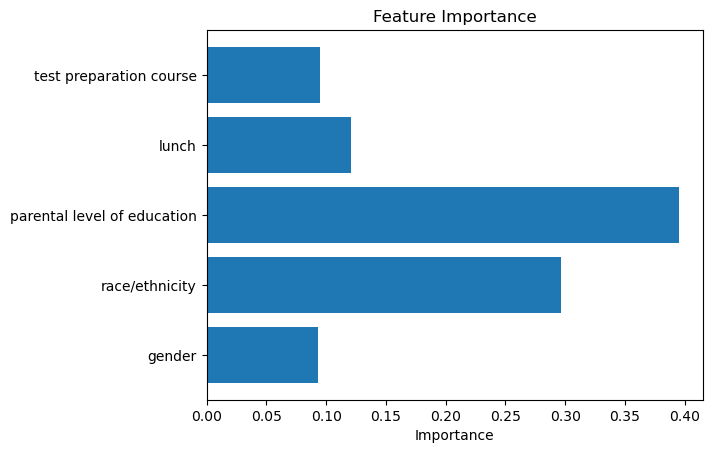

In [17]:
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

## Problem Statement
Predict whether a student will pass or fail based on demographic and background information, without using exam scores.


##  Predict New Student
Prediction is the process of using a trained machine learning model to determine the output for new, unseen data.

In [19]:
new_student = pd.DataFrame({
    'gender': [1],
    'race/ethnicity': [2],
    'parental level of education': [3],
    'lunch': [1],
    'test preparation course': [1]
})

prediction = model.predict(new_student)

print("Prediction:", "PASS" if prediction[0] == 1 else "FAIL")


Prediction: PASS


## Conclusion

This project demonstrates the effective use of machine learning to predict student academic performance using the Students Performance in Exams dataset. The Random Forest Classifier provided reliable and accurate predictions by analyzing both academic and demographic factors. The results show that features such as average score and test preparation have a significant impact on student outcomes. Overall, the model proves that data-driven approaches can help identify students at risk and support better educational decision-making.